# Knorus Price Prediction

It's a price prediction pipeline for books from metadata and text. We clean the fields, split the data, build features, check PCA sizes, compare models through MLflow, and save the final version for production use.


## Target and feature design

We predict `Цена (руб.)` from the book record. The target is trained in `log1p(price)` space, which makes the price distribution less skewed and allows us to process expensive books not as outliers. We drop unsignificant fields: `Код издания`, `Автор`, `ISBN`, `Ссылка на ЭБС`.

The remaining columns are handled as follows.

- `Название` is cleaned from the trailing template and merged with `Аннотация`.
- `Гриф` becomes a binary feature.
- `Обл/пер` becomes a 0 / 1 feature.
- `Год издания`, `Кол-во страниц`, and `Формат` stay numeric and are standardized.
- `Вид издания` and `Издательство` are encoded as categories.
- `Серия` is treated as multi-hot.
- `Дисциплина` and `Тематика` are embedded with Qwen and then compressed with PCA.
- `Название + Аннотация` is embedded as one semantic block and checked for the component count needed to reach 95 percent explained variance.
- A median predictor is included as a reference model during selection.


In [ ]:
!pip -q install "transformers>=4.46.0" accelerate datasets huggingface_hub mlflow scikit-learn pandas numpy matplotlib pyarrow safetensors faiss-cpu joblib tqdm

In [ ]:
!pip install -U transformers torchao

In [ ]:
import json
import os
import re
from collections import OrderedDict
from pathlib import Path

import joblib
import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from huggingface_hub import hf_hub_download, HfApi
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
DATASET_ID = "pymlex/knorus-price-list"
DATA_FILE = "train.csv"
TARGET_COL = "Цена (руб.)"
TARGET_TRANSFORM = "log1p"

DROP_COLS = ["Код издания", "Автор", "ISBN", "Ссылка на ЭБС"]

TEXT_TITLE_COL = "Название"
TEXT_ANN_COL = "Аннотация"
TEXT_TITLE_CORE_COL = "title_core"
TEXT_TITLE_ANN_COL = "title_annotation_text"

NUM_COLS = ["Год издания", "Кол-во страниц"]
FORMAT_COL = "Формат"
FORMAT_NUM_COLS = ["format_w", "format_h", "format_n"]

BIN_COLS = ["grif_bin", "cover_bin"]

CAT_COLS = ["Вид издания", "Издательство"]

MULTILABEL_COL = "Серия"
DISC_COL = "Дисциплина"
THEME_COL = "Тематика"

TITLE_ANN_PCA = 128
DISC_PCA = 64
THEME_PCA = 64

EMBED_MODEL_ID = "Qwen/Qwen3.5-0.8B-Base"
EMBED_MAX_LEN_TITLE_ANN = 512
EMBED_MAX_LEN_DISC_THEME = 96
EMBED_BATCH_SIZE = 8

In [ ]:
artifacts_dir = Path("/content/knorus_artifacts")
plots_dir = artifacts_dir / "plots"
cache_dir = artifacts_dir / "cache"
models_dir = artifacts_dir / "models"
for p in [artifacts_dir, plots_dir, cache_dir, models_dir]:
    p.mkdir(parents=True, exist_ok=True)

mlflow_dir = artifacts_dir / "mlruns"
mlflow.set_tracking_uri(f"file:{mlflow_dir}")
mlflow.set_experiment("knorus-price-prediction")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/16 10:37:03 INFO mlflow.tracking.fluent: Experiment with name 'knorus-price-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/knorus_artifacts/mlruns/491553779383231180', creation_time=1778927823254, experiment_id='491553779383231180', last_update_time=1778927823254, lifecycle_stage='active', name='knorus-price-prediction', tags={}, trace_location=None, workspace='default'>

In [ ]:
file_path = hf_hub_download(
    repo_id=DATASET_ID,
    filename=DATA_FILE,
    repo_type="dataset"
)

df = pd.read_csv(file_path)
df = df.replace(r"^\s*$", np.nan, regex=True)
df.columns = df.columns.astype(str).str.strip()

print(df.shape)
display(df.head(3))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.csv:   0%|          | 0.00/18.0M [00:00<?, ?B/s]

(8188, 18)


,Код издания,Цена (руб.),Название,Автор,Год издания,Гриф,Вид издания,Серия,Издательство,Дисциплина,Тематика,Вуз автора,Аннотация,Кол-во страниц,Обл/пер,Формат,ISBN,Ссылка на ЭБС
0,718570,1440,Актуальные вопросы обеспечения экономической б...,"Близкий Р.С. (под общ. ред.), Рогуленко Т.М., ...",2026,Без грифа,Монография,Аспирантура;Бакалавриат;Магистратура,Русайнс,Экономическая безопасность,Экономика,Государственный университет управления,В работе анализируются тенденции развития экон...,150,Обложка,60х90/16,978-5-466-11698-4,https://book.ru/book/962953
1,717881,1440,"Английский язык для группы специальностей ""Инф...","Серебрякова О.М., Буравлева А.К.",2026,Рекомендовано Экспертным советом УМО в системе...,Учебное пособие,СПО,КноРус,Английский язык в профессиональной деятельности,Английский язык;Информационная безопасность,Московский университет Министерства внутренних...,Содержит профессионально ориентированные аутен...,208,Переплет,60х90/16,978-5-406-16303-0,NaN
2,710622,1440,"Английский язык для направления ""Спортивный ме...","Мельничук М.В., Васьбиева Д.Г., Калугина О.А.",2026,Рекомендовано Экспертным советом УМО в системе...,Учебник,Бакалавриат,КноРус,Иностранный язык в профессиональной сфере,Английский язык;Менеджмент в отдельных отраслях,Финансовый университет при Правительстве Росси...,Нацелен на совершенствование иноязычной профес...,176,Переплет,60х90/16,978-5-406-15653-7,NaN


## Initial exploration


In [ ]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nunique": df.nunique(dropna=True),
    "missing": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4)
}).sort_values("missing_rate", ascending=False)

display(summary)

,dtype,nunique,missing,missing_rate
Вуз автора,object,771,556,0.0679
Ссылка на ЭБС,object,8123,65,0.0079
Цена (руб.),int64,100,0,0.0000
Код издания,int64,8188,0,0.0000
Название,object,8009,0,0.0000
Автор,object,6166,0,0.0000
Вид издания,object,24,0,0.0000
Серия,object,172,0,0.0000
Год издания,int64,3,0,0.0000
Гриф,object,2955,0,0.0000


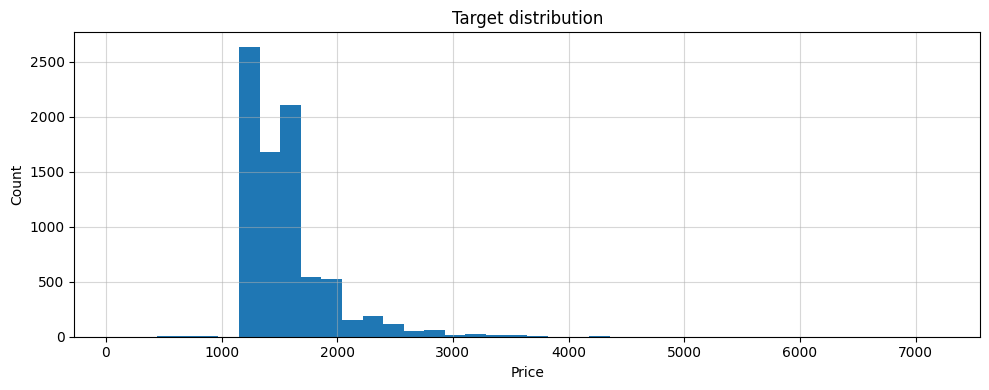

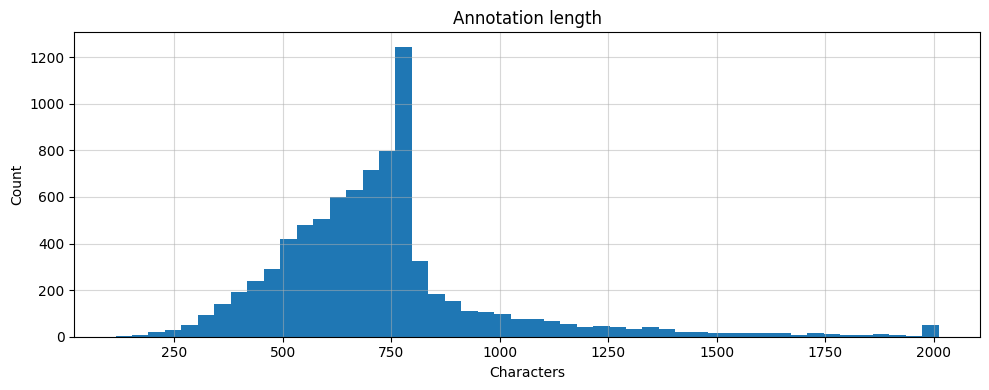

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[TARGET_COL].dropna(), bins=40)
ax.set_title("Target distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(plots_dir / "target_distribution.png", dpi=160)
plt.grid(alpha=0.5)
plt.show()

ann_lengths = df[TEXT_ANN_COL].dropna().astype(str).str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ann_lengths, bins=50)
ax.set_title("Annotation length")
ax.set_xlabel("Characters")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(plots_dir / "annotation_length.png", dpi=160)
plt.grid(alpha=0.5)
plt.show()

## Text normalization and field parsing

Here we process categorial columns. The title is stripped of the trailing template that duplicates other columns. Format is split into three numeric parts. Grif becomes a binary flag. Series stays as a set of independent labels. Discipline and theme are split on `;`, because one cell can contain multiple semantic categories.


In [ ]:
def normalize_spaces(text):
    if pd.isna(text):
        return ""
    text = str(text).replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_core_title(text):
    s = normalize_spaces(text)
    if not s:
        return ""
    base = s.rstrip(".").strip()
    if base.count(".") >= 2:
        return base.rsplit(".", 2)[0].strip()
    return base

def compose_title_annotation(title, ann):
    title = normalize_spaces(title)
    ann = normalize_spaces(ann)
    parts = []
    if title:
        parts.append(f"Title: {title}")
    if ann:
        parts.append(f"Annotation: {ann}")
    return " \n ".join(parts)

def parse_format(text):
    s = normalize_spaces(text).lower().replace("x", "х").replace("*", "х")
    s = s.replace(" ", "")
    if not s:
        return [np.nan, np.nan, np.nan]
    m = re.match(r"^(\d+)х(\d+)/(\d+)$", s)
    if m:
        return [float(m.group(1)), float(m.group(2)), float(m.group(3))]
    return [np.nan, np.nan, np.nan]

def split_labels(text):
    s = normalize_spaces(text)
    if not s:
        return []
    return [normalize_spaces(x) for x in s.split(";") if normalize_spaces(x)]

def grif_to_bin(text):
    s = normalize_spaces(text).lower()
    if not s or s == "без грифа":
        return 0
    return 1

def cover_to_bin(text):
    s = normalize_spaces(text).lower()
    if s == "переплет":
        return 1
    if s == "обложка":
        return 0
    return np.nan


In [ ]:
work = df.copy()

work[TARGET_COL] = pd.to_numeric(work[TARGET_COL], errors="coerce")
work = work.dropna(subset=[TARGET_COL]).reset_index(drop=True)

work[TEXT_TITLE_CORE_COL] = work[TEXT_TITLE_COL].map(extract_core_title)
work[TEXT_TITLE_ANN_COL] = work.apply(
    lambda row: compose_title_annotation(row[TEXT_TITLE_CORE_COL], row[TEXT_ANN_COL]),
    axis=1
)

work["format_parsed"] = work[FORMAT_COL].map(parse_format)
work[FORMAT_NUM_COLS] = pd.DataFrame(work["format_parsed"].tolist(), index=work.index)
work = work.drop(columns=["format_parsed"])

work["grif_bin"] = work["Гриф"].map(grif_to_bin)
work["cover_bin"] = work["Обл/пер"].map(cover_to_bin)

work

,Код издания,Цена (руб.),Название,Автор,Год издания,Гриф,Вид издания,Серия,Издательство,Дисциплина,...,Формат,ISBN,Ссылка на ЭБС,title_core,title_annotation_text,format_w,format_h,format_n,grif_bin,cover_bin
0,718570,1440,Актуальные вопросы обеспечения экономической б...,"Близкий Р.С. (под общ. ред.), Рогуленко Т.М., ...",2026,Без грифа,Монография,Аспирантура;Бакалавриат;Магистратура,Русайнс,Экономическая безопасность,...,60х90/16,978-5-466-11698-4,https://book.ru/book/962953,Актуальные вопросы обеспечения экономической б...,Title: Актуальные вопросы обеспечения экономич...,60.0,90.0,16.0,0,0
1,717881,1440,"Английский язык для группы специальностей ""Инф...","Серебрякова О.М., Буравлева А.К.",2026,Рекомендовано Экспертным советом УМО в системе...,Учебное пособие,СПО,КноРус,Английский язык в профессиональной деятельности,...,60х90/16,978-5-406-16303-0,NaN,"Английский язык для группы специальностей ""Инф...",Title: Английский язык для группы специальност...,60.0,90.0,16.0,1,1
2,710622,1440,"Английский язык для направления ""Спортивный ме...","Мельничук М.В., Васьбиева Д.Г., Калугина О.А.",2026,Рекомендовано Экспертным советом УМО в системе...,Учебник,Бакалавриат,КноРус,Иностранный язык в профессиональной сфере,...,60х90/16,978-5-406-15653-7,NaN,"Английский язык для направления ""Спортивный ме...","Title: Английский язык для направления ""Спорти...",60.0,90.0,16.0,1,1
3,713300,2280,Английский язык для специалистов в сфере инфор...,"Краснова Т.И., Мельничук М.В.",2027,Рекомендовано Экспертным советом УМО в системе...,Учебник,Бакалавриат,КноРус,Английский язык,...,60х90/16,978-5-406-16720-5,NaN,Английский язык для специалистов в сфере инфор...,Title: Английский язык для специалистов в сфер...,60.0,90.0,16.0,1,1
4,721660,1320,Архивное дело в суде. (СПО). Учебник.,Жукова П.Д.,2027,Рекомендовано Экспертным советом УМО в системе...,Учебник,СПО,КноРус,Архивное дело в суде,...,60х90/16,978-5-406-16771-7,https://book.ru/book/962409,Архивное дело в суде,Title: Архивное дело в суде \n Annotation: Сод...,60.0,90.0,16.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8183,692942,2040,Языковая личность политика: особенности формир...,"Алексеев А.Б., Сорокина Э.А.",2026,Без грифа,Монография,Аспирантура;Бакалавриат;Магистратура,Русайнс,Основы деловой и публичной коммуникации;Лингви...,...,60х90/16,978-5-466-05563-4,https://book.ru/book/953464,Языковая личность политика: особенности формир...,Title: Языковая личность политика: особенности...,60.0,90.0,16.0,0,0
8184,709265,1200,Языковое творчество в современных мультимодаль...,Таймур М.П.,2026,Без грифа,Монография,Аспирантура;Бакалавриат;Магистратура,Русайнс,Теоретическая и прикладная лингвистика,...,60х90/16,978-5-466-09307-0,https://book.ru/book/949393,Языковое творчество в современных мультимодаль...,Title: Языковое творчество в современных мульт...,60.0,90.0,16.0,0,0
8185,717394,1440,"Языковые модели (LLM) для интерпретации, генер...","Золкин А.Л., Рамазанов И.А., Логунова Н.Ю., Ве...",2026,Без грифа,Учебник,Аспирантура;Бакалавриат;Магистратура,Русайнс,Большие данные и машинное обучение,...,60х90/16,978-5-466-11261-0,https://book.ru/book/962323,"Языковые модели (LLM) для интерпретации, генер...",Title: Языковые модели (LLM) для интерпретации...,60.0,90.0,16.0,0,0
8186,716388,1440,"Японский опыт мотивации труда. (Аспирантура, М...",Волгин Н.А.,2026,Без грифа,Монография,Аспирантура,КноРус,Мотивация и стимулирование трудовой деятельности,...,60х90/16,978-5-406-15786-2,https://book.ru/book/942087,Японский опыт мотивации труда,Title: Японский опыт мотивации труда \n Annota...,60.0,90.0,16.0,0,0


In [ ]:
price_bins = pd.qcut(work[TARGET_COL], q=10, labels=False, duplicates="drop")

train_valid_df, test_df = train_test_split(
    work,
    test_size=0.075,
    random_state=SEED,
    stratify=price_bins
)

valid_bins = pd.qcut(train_valid_df[TARGET_COL], q=10, labels=False, duplicates="drop")

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.025 / 0.925,
    random_state=SEED,
    stratify=valid_bins
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df.shape, valid_df.shape, test_df.shape)

(7368, 25) (205, 25) (615, 25)


## Numeric features

`Год издания`, `Кол-во страниц`, and the three numbers extracted from `Формат` are standardized. `Формат` carries structural information and handled as ordered numbers.


In [ ]:
def fit_numeric_block(train_frame, valid_frame, test_frame):
    numeric_cols = NUM_COLS + FORMAT_NUM_COLS

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    x_train = imputer.fit_transform(train_frame[numeric_cols])
    x_valid = imputer.transform(valid_frame[numeric_cols])
    x_test = imputer.transform(test_frame[numeric_cols])

    x_train = scaler.fit_transform(x_train)
    x_valid = scaler.transform(x_valid)
    x_test = scaler.transform(x_test)

    return {
        "imputer": imputer,
        "scaler": scaler,
        "x_train": x_train.astype(np.float32),
        "x_valid": x_valid.astype(np.float32),
        "x_test": x_test.astype(np.float32),
        "feature_names": numeric_cols
    }

numeric_bundle = fit_numeric_block(train_df, valid_df, test_df)
numeric_bundle["x_train"].shape

(7368, 5)

## Low-cardinality categories

`Вид издания` and `Издательство` are encoded with one-hot and `handle_unknown='ignore'`. But, of course, it is better to use hashes or other approaches to handle new publishers. For now it is out of scope.

In [ ]:
def fit_ohe(train_frame, valid_frame, test_frame, column):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    x_train = encoder.fit_transform(train_frame[[column]].fillna("__missing__"))
    x_valid = encoder.transform(valid_frame[[column]].fillna("__missing__"))
    x_test = encoder.transform(test_frame[[column]].fillna("__missing__"))
    return {
        "encoder": encoder,
        "x_train": x_train.astype(np.float32),
        "x_valid": x_valid.astype(np.float32),
        "x_test": x_test.astype(np.float32),
        "feature_names": list(encoder.get_feature_names_out([column]))
    }

edition_bundle = fit_ohe(train_df, valid_df, test_df, "Вид издания")
publisher_bundle = fit_ohe(train_df, valid_df, test_df, "Издательство")

print(edition_bundle["x_train"].shape, publisher_bundle["x_train"].shape)

(7368, 24) (7368, 5)


In [ ]:
def fit_binary(train_frame, valid_frame, test_frame, column):
    med = train_frame[column].dropna().mode()
    fill_value = int(med.iloc[0]) if len(med) else 0
    x_train = train_frame[column].fillna(fill_value).astype(float).to_numpy().reshape(-1, 1)
    x_valid = valid_frame[column].fillna(fill_value).astype(float).to_numpy().reshape(-1, 1)
    x_test = test_frame[column].fillna(fill_value).astype(float).to_numpy().reshape(-1, 1)
    return {
        "fill_value": fill_value,
        "x_train": x_train.astype(np.float32),
        "x_valid": x_valid.astype(np.float32),
        "x_test": x_test.astype(np.float32),
        "feature_names": [column]
    }

grif_bundle = fit_binary(train_df, valid_df, test_df, "grif_bin")
cover_bundle = fit_binary(train_df, valid_df, test_df, "cover_bin")

In [ ]:
def build_multilabel_vocab(train_lists):
    vocab = sorted(set(label for labels in train_lists for label in labels))
    index = {label: i for i, label in enumerate(vocab)}
    return vocab, index

def multilabel_matrix(list_of_lists, index):
    x = np.zeros((len(list_of_lists), len(index)), dtype=np.float32)
    for i, labels in enumerate(list_of_lists):
        for label in labels:
            j = index.get(label)
            if j is not None:
                x[i, j] = 1.0
    return x

series_train_lists = train_df[MULTILABEL_COL].map(split_labels).tolist()
series_valid_lists = valid_df[MULTILABEL_COL].map(split_labels).tolist()
series_test_lists = test_df[MULTILABEL_COL].map(split_labels).tolist()

series_vocab, series_index = build_multilabel_vocab(series_train_lists)
series_train = multilabel_matrix(series_train_lists, series_index)
series_valid = multilabel_matrix(series_valid_lists, series_index)
series_test = multilabel_matrix(series_test_lists, series_index)

series_train.shape, len(series_vocab)

((7368, 84), 84)

In [ ]:
text_cache_dir = cache_dir / "embeddings"
text_cache_dir.mkdir(parents=True, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    EMBED_MODEL_ID,
    torch_dtype=torch.float16,
    trust_remote_code=True
).to(device)
model.eval()
model.config.use_cache = False

def mean_pool(hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(hidden_state)
    summed = (hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

@torch.inference_mode()
def embed_texts(texts, max_length, batch_size):
    vectors = []
    for start in tqdm(range(0, len(texts), batch_size)):
        batch = texts[start:start + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        out = model(
            **enc,
            output_hidden_states=True,
            return_dict=True
        )
        hidden = out.hidden_states[-1]
        pooled = mean_pool(hidden, enc["attention_mask"])
        vectors.append(pooled.float().cpu().numpy())
    return np.vstack(vectors)

def build_cache_from_texts(texts, cache_name, max_length, batch_size):
    cache_path = text_cache_dir / f"{cache_name}.pt"
    cache = {}
    if cache_path.exists():
        cache = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=False
        )
    unique_texts = [t for t in OrderedDict.fromkeys(texts) if t]
    missing = [t for t in unique_texts if t not in cache]
    if missing:
        missing_vectors = embed_texts(missing, max_length=max_length, batch_size=batch_size)
        for text, vector in zip(missing, missing_vectors):
            cache[text] = vector.astype(np.float32)
        torch.save(cache, cache_path)
    return cache

def get_cached_vectors(texts, cache, cache_name, max_length, batch_size):
    unique_texts = [t for t in OrderedDict.fromkeys(texts) if t]
    missing = [t for t in unique_texts if t not in cache]
    if missing:
        missing_vectors = embed_texts(missing, max_length=max_length, batch_size=batch_size)
        for text, vector in zip(missing, missing_vectors):
            cache[text] = vector.astype(np.float32)
        torch.save(cache, text_cache_dir / f"{cache_name}.pt")
    return np.vstack([cache[t] if t else np.zeros(next(iter(cache.values())).shape, dtype=np.float32) for t in texts])

train_title_ann_cache = build_cache_from_texts(
    train_df[TEXT_TITLE_ANN_COL].fillna("").tolist(),
    "title_annotation",
    EMBED_MAX_LEN_TITLE_ANN,
    EMBED_BATCH_SIZE
)

train_disc_cache = build_cache_from_texts(
    [label for labels in train_df[DISC_COL].map(split_labels) for label in labels],
    "discipline",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

train_theme_cache = build_cache_from_texts(
    [label for labels in train_df[THEME_COL].map(split_labels) for label in labels],
    "theme",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

len(train_title_ann_cache), len(train_disc_cache), len(train_theme_cache)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/921 [00:00<?, ?it/s]

  0%|          | 0/383 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

(7368, 3063, 157)

In [ ]:
def row_mean_embeddings(list_of_lists, cache, cache_name, max_length, batch_size):
    zero = np.zeros(next(iter(cache.values())).shape, dtype=np.float32) if cache else None
    all_texts = [label for labels in list_of_lists for label in labels if label]
    if all_texts:
        cache = build_cache_from_texts(all_texts, cache_name, max_length, batch_size)
        zero = np.zeros(next(iter(cache.values())).shape, dtype=np.float32)
    rows = []
    for labels in list_of_lists:
        vectors = [cache[label] for label in labels if label in cache]
        if len(vectors) == 0:
            rows.append(zero)
        else:
            rows.append(np.mean(np.stack(vectors, axis=0), axis=0))
    return np.vstack(rows).astype(np.float32), cache

train_disc_lists = train_df[DISC_COL].map(split_labels).tolist()
valid_disc_lists = valid_df[DISC_COL].map(split_labels).tolist()
test_disc_lists = test_df[DISC_COL].map(split_labels).tolist()

train_theme_lists = train_df[THEME_COL].map(split_labels).tolist()
valid_theme_lists = valid_df[THEME_COL].map(split_labels).tolist()
test_theme_lists = test_df[THEME_COL].map(split_labels).tolist()

train_title_ann_vectors = np.vstack([train_title_ann_cache[text] for text in train_df[TEXT_TITLE_ANN_COL].fillna("").tolist()]).astype(np.float32)

valid_title_ann_cache = dict(train_title_ann_cache)
valid_title_ann_vectors = get_cached_vectors(
    valid_df[TEXT_TITLE_ANN_COL].fillna("").tolist(),
    valid_title_ann_cache,
    "title_annotation",
    EMBED_MAX_LEN_TITLE_ANN,
    EMBED_BATCH_SIZE
)

test_title_ann_cache = dict(valid_title_ann_cache)
test_title_ann_vectors = get_cached_vectors(
    test_df[TEXT_TITLE_ANN_COL].fillna("").tolist(),
    test_title_ann_cache,
    "title_annotation",
    EMBED_MAX_LEN_TITLE_ANN,
    EMBED_BATCH_SIZE
)

train_disc_vectors, train_disc_cache = row_mean_embeddings(
    train_disc_lists,
    train_disc_cache,
    "discipline",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

valid_disc_vectors, valid_disc_cache = row_mean_embeddings(
    valid_disc_lists,
    train_disc_cache,
    "discipline",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

test_disc_vectors, test_disc_cache = row_mean_embeddings(
    test_disc_lists,
    valid_disc_cache,
    "discipline",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

train_theme_vectors, train_theme_cache = row_mean_embeddings(
    train_theme_lists,
    train_theme_cache,
    "theme",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

valid_theme_vectors, valid_theme_cache = row_mean_embeddings(
    valid_theme_lists,
    train_theme_cache,
    "theme",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

test_theme_vectors, test_theme_cache = row_mean_embeddings(
    test_theme_lists,
    valid_theme_cache,
    "theme",
    EMBED_MAX_LEN_DISC_THEME,
    EMBED_BATCH_SIZE
)

train_title_ann_vectors.shape, train_disc_vectors.shape, train_theme_vectors.shape

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

((7368, 1024), (7368, 1024), (7368, 1024))

## PCA for semantic vectors

The semantic blocks are reduced after an explained-variance check. We keep 128 components for `Название + Аннотация`, 64 for `Дисциплина`, and 64 for `Тематика`. It allows us to compress embeddings for faster inference, we also have only 8k samples in the dataset. However, the cumulative variance curve and the component count needed to reach 95 percent are plotted and leaves us no choice but to use more components.

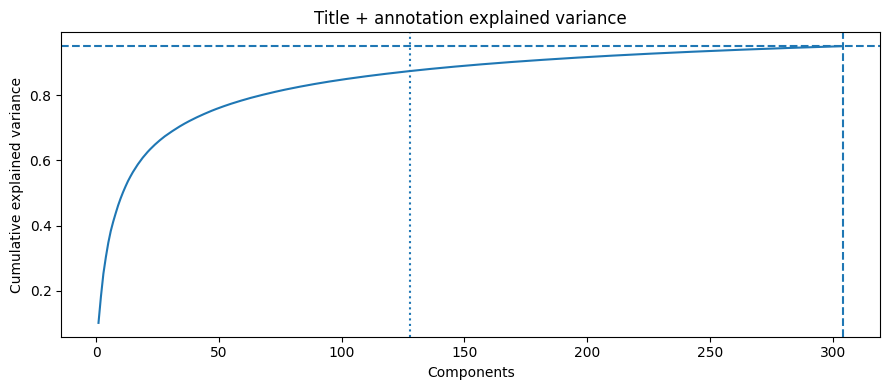

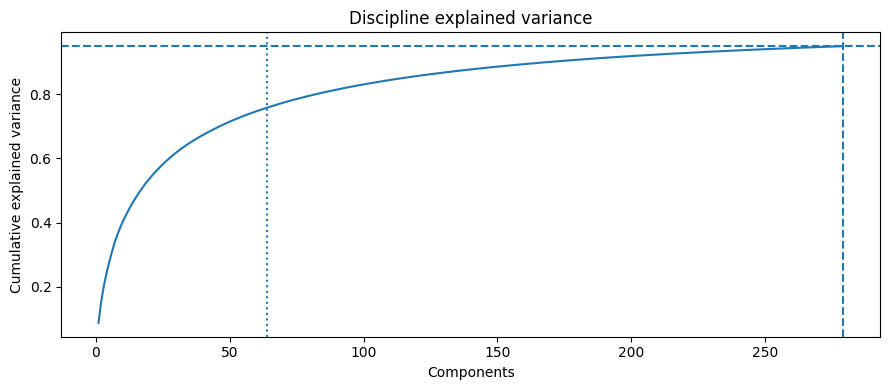

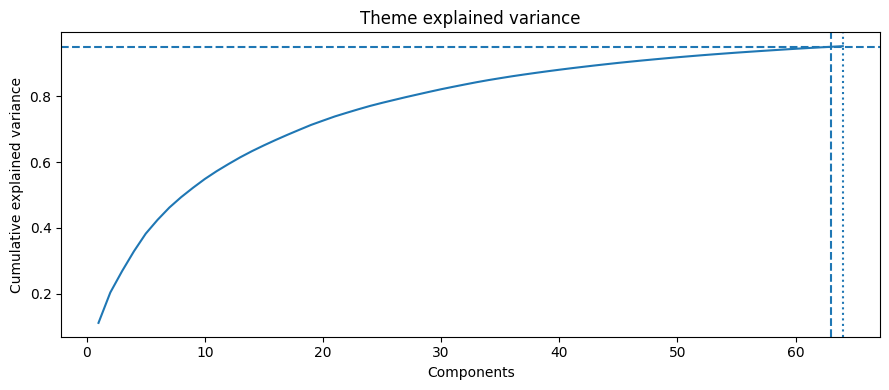

Title + annotation n95: 304
Discipline n95: 279
Theme n95: 63


In [ ]:
def fit_pca_and_plot(matrix, chosen_components, title, filename):
    pca_full = PCA(random_state=SEED)
    pca_full.fit(matrix)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n95 = int(np.searchsorted(cum, 0.95) + 1)
    n_plot = min(len(cum), max(chosen_components, n95))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(np.arange(1, n_plot + 1), cum[:n_plot])
    ax.axhline(0.95, linestyle="--")
    ax.axvline(n95, linestyle="--")
    ax.axvline(chosen_components, linestyle=":")
    ax.set_title(title)
    ax.set_xlabel("Components")
    ax.set_ylabel("Cumulative explained variance")
    fig.tight_layout()
    fig.savefig(plots_dir / filename, dpi=160)
    plt.show()

    pca_final = PCA(n_components=min(chosen_components, matrix.shape[1]), random_state=SEED)
    pca_final.fit(matrix)

    return {
        "pca_full": pca_full,
        "pca_final": pca_final,
        "n95": n95,
        "cum": cum
    }

title_pca_bundle = fit_pca_and_plot(
    train_title_ann_vectors,
    TITLE_ANN_PCA,
    "Title + annotation explained variance",
    "pca_title_annotation.png"
)

disc_pca_bundle = fit_pca_and_plot(
    train_disc_vectors,
    DISC_PCA,
    "Discipline explained variance",
    "pca_discipline.png"
)

theme_pca_bundle = fit_pca_and_plot(
    train_theme_vectors,
    THEME_PCA,
    "Theme explained variance",
    "pca_theme.png"
)

print("Title + annotation n95:", title_pca_bundle["n95"])
print("Discipline n95:", disc_pca_bundle["n95"])
print("Theme n95:", theme_pca_bundle["n95"])

In [ ]:
train_title_ann_pca = title_pca_bundle["pca_final"].transform(train_title_ann_vectors).astype(np.float32)
valid_title_ann_pca = title_pca_bundle["pca_final"].transform(valid_title_ann_vectors).astype(np.float32)
test_title_ann_pca = title_pca_bundle["pca_final"].transform(test_title_ann_vectors).astype(np.float32)

train_disc_pca = disc_pca_bundle["pca_final"].transform(train_disc_vectors).astype(np.float32)
valid_disc_pca = disc_pca_bundle["pca_final"].transform(valid_disc_vectors).astype(np.float32)
test_disc_pca = disc_pca_bundle["pca_final"].transform(test_disc_vectors).astype(np.float32)

train_theme_pca = theme_pca_bundle["pca_final"].transform(train_theme_vectors).astype(np.float32)
valid_theme_pca = theme_pca_bundle["pca_final"].transform(valid_theme_vectors).astype(np.float32)
test_theme_pca = theme_pca_bundle["pca_final"].transform(test_theme_vectors).astype(np.float32)

train_title_ann_pca.shape, train_disc_pca.shape, train_theme_pca.shape

((7368, 128), (7368, 64), (7368, 64))

In [ ]:
def assemble_features(numeric, edition, publisher, grif, cover, series, title_ann, disc, theme):
    return np.hstack([numeric, edition, publisher, grif, cover, series, title_ann, disc, theme]).astype(np.float32)

X_train = assemble_features(
    numeric_bundle["x_train"],
    edition_bundle["x_train"],
    publisher_bundle["x_train"],
    grif_bundle["x_train"],
    cover_bundle["x_train"],
    series_train,
    train_title_ann_pca,
    train_disc_pca,
    train_theme_pca
)

X_valid = assemble_features(
    numeric_bundle["x_valid"],
    edition_bundle["x_valid"],
    publisher_bundle["x_valid"],
    grif_bundle["x_valid"],
    cover_bundle["x_valid"],
    series_valid,
    valid_title_ann_pca,
    valid_disc_pca,
    valid_theme_pca
)

X_test = assemble_features(
    numeric_bundle["x_test"],
    edition_bundle["x_test"],
    publisher_bundle["x_test"],
    grif_bundle["x_test"],
    cover_bundle["x_test"],
    series_test,
    test_title_ann_pca,
    test_disc_pca,
    test_theme_pca
)

y_train = train_df[TARGET_COL].to_numpy(dtype=np.float32)
y_valid = valid_df[TARGET_COL].to_numpy(dtype=np.float32)
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)

y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

print("Train features:", X_train.shape)
print("Valid features:", X_valid.shape)
print("Test features:", X_test.shape)

feature_count = X_train.shape[1]
print("Total feature count:", feature_count)


Train features: (7368, 376)
Valid features: (205, 376)
Test features: (615, 376)
Total feature count: 376


## Baseline models

We compare tabular models first. A constant median predictor is included as a baseline before the neural network.


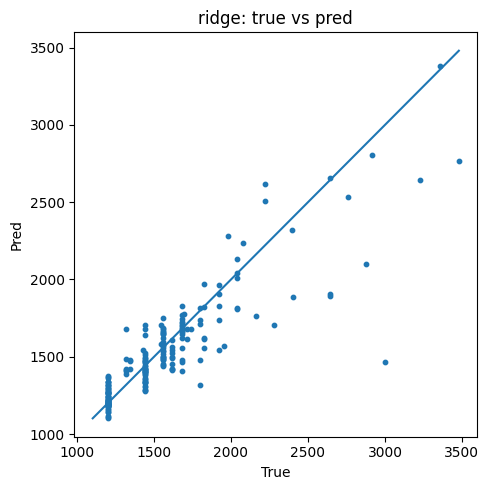

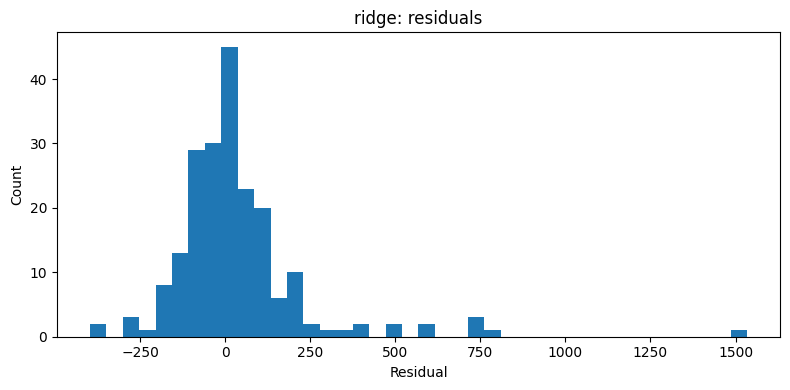

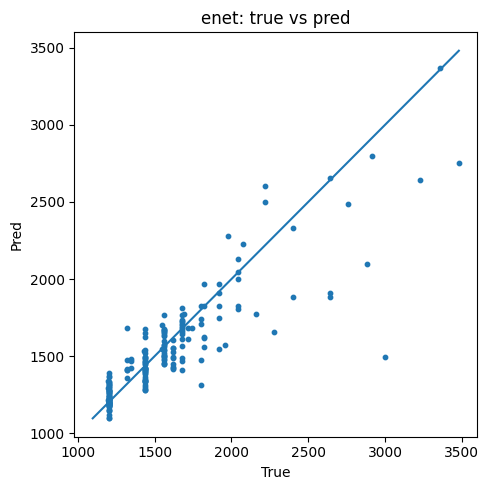

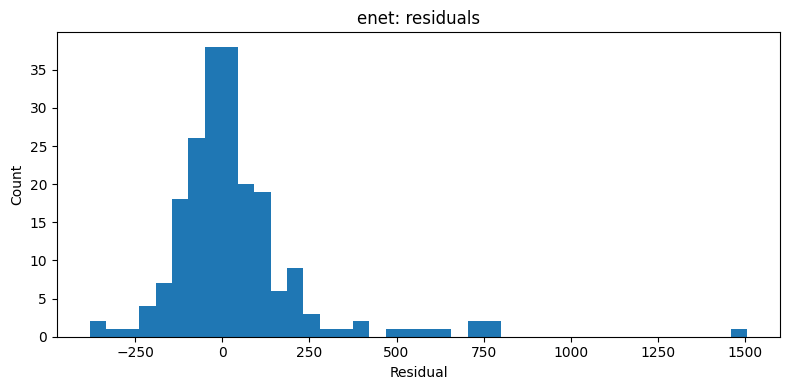

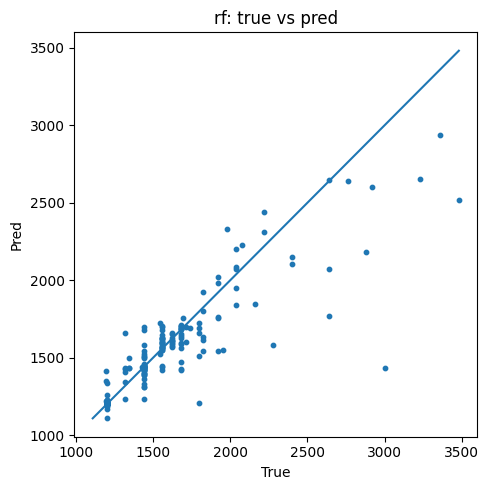

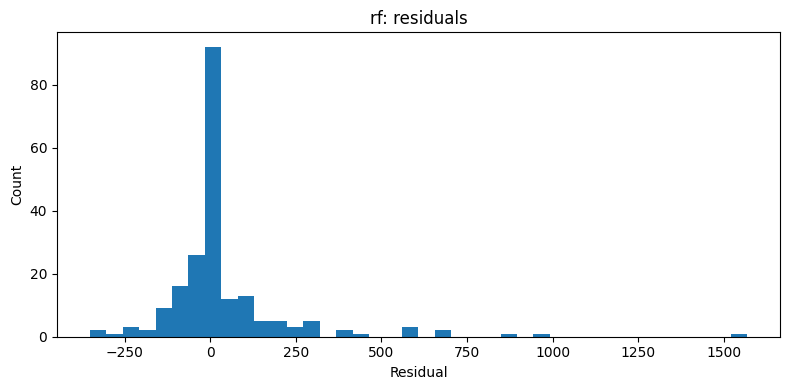

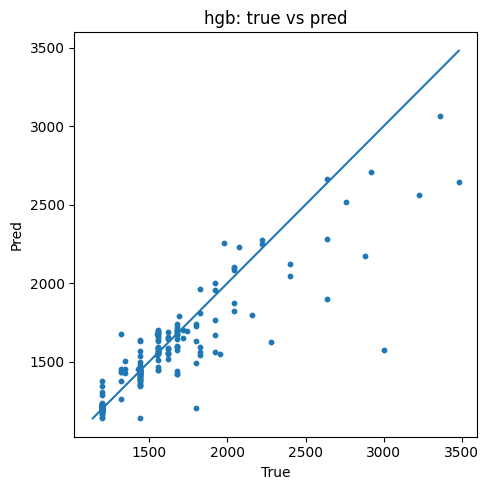

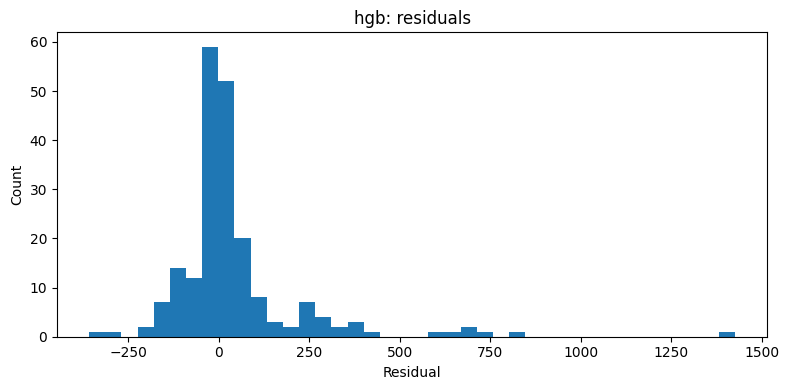

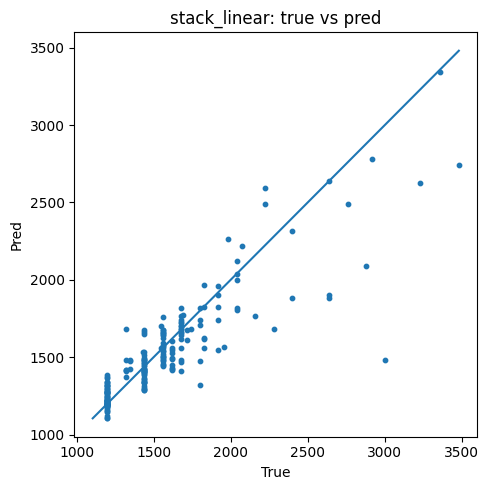

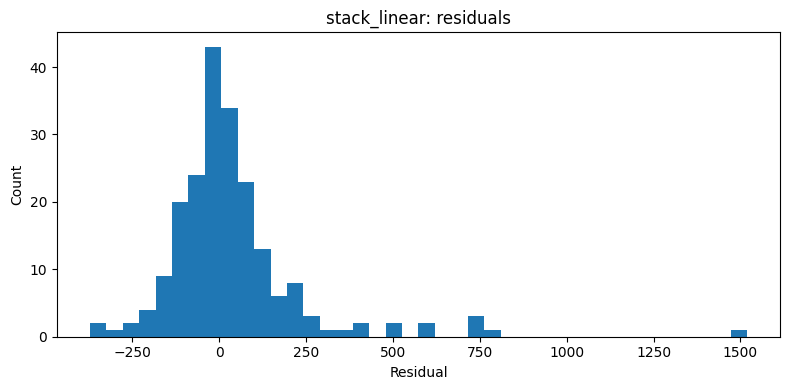

,model,mae,rmse,r2
0,hgb,96.856537,192.598382,0.786973
1,rf,96.668777,204.667346,0.759438
2,enet,117.096420,204.841879,0.759027
3,ridge,117.546837,205.419407,0.757667
4,stack_linear,117.365952,205.838776,0.756676


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def price_to_log(values):
    return np.log1p(np.asarray(values, dtype=np.float32))

def log_to_price(values):
    return np.expm1(np.asarray(values, dtype=np.float32))

def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "r2": float(r2_score(y_true, y_pred))
    }

def save_regression_plots(y_true, y_pred, name):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_true, y_pred, s=10)
    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max())
    ]
    ax.plot(lims, lims)
    ax.set_title(f"{name}: true vs pred")
    ax.set_xlabel("True")
    ax.set_ylabel("Pred")
    fig.tight_layout()
    fig.savefig(plots_dir / f"{name}_true_pred.png", dpi=160)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(residuals, bins=40)
    ax.set_title(f"{name}: residuals")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    fig.tight_layout()
    fig.savefig(plots_dir / f"{name}_residuals.png", dpi=160)
    plt.show()

def fit_and_score_sklearn(model, model_name, X_tr, y_tr_log, X_va, y_va_raw, params):
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params({**params, "target_transform": TARGET_TRANSFORM})
        model.fit(X_tr, y_tr_log)
        pred_log = model.predict(X_va)
        pred = log_to_price(pred_log)
        metrics = regression_metrics(y_va_raw, pred)
        mlflow.log_metrics({f"valid_{k}": v for k, v in metrics.items()})
        save_regression_plots(y_va_raw, pred, model_name)
        for key, value in metrics.items():
            mlflow.log_metric(f"valid_{key}", value)
    return model, metrics, pred

candidate_models = {
    "ridge": (
        Ridge(alpha=5.0, random_state=SEED),
        {"alpha": 5.0}
    ),
    "enet": (
        ElasticNet(alpha=0.001, l1_ratio=0.15, random_state=SEED, max_iter=10000),
        {"alpha": 0.001, "l1_ratio": 0.15}
    ),
    "rf": (
        RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        ),
        {"n_estimators": 400, "min_samples_leaf": 2}
    ),
    "hgb": (
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=500,
            random_state=SEED
        ),
        {"learning_rate": 0.05, "max_depth": 6, "max_iter": 500}
    ),
    "stack_linear": (
        StackingRegressor(
            estimators=[
                ("ridge", Ridge(alpha=5.0, random_state=SEED)),
                ("enet", ElasticNet(alpha=0.001, l1_ratio=0.15, random_state=SEED, max_iter=10000)),
                ("sgd", SGDRegressor(loss="huber", alpha=0.0001, max_iter=5000, random_state=SEED))
            ],
            final_estimator=Ridge(alpha=1.0, random_state=SEED),
            n_jobs=-1
        ),
        {"estimators": "ridge+enet+sgd", "final_estimator": "ridge"}
    )
}

leaderboard = []
fitted_models = {}

for name, (model, params) in candidate_models.items():
    fitted, metrics, pred = fit_and_score_sklearn(model, name, X_train, y_train_log, X_valid, y_valid, params)
    fitted_models[name] = fitted
    leaderboard.append({"model": name, **metrics})

leaderboard_df = pd.DataFrame(leaderboard).sort_values("rmse").reset_index(drop=True)
display(leaderboard_df)


## Torch model

We use SwiGLU blocks and Huber loss here. The target is modeled as `log1p(price)` and then standardized.

In [ ]:
class PriceDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class SwiGLUBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim * 2)
        self.proj = nn.Linear(out_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        a, b = self.fc(x).chunk(2, dim=-1)
        x = a * F.silu(b)
        x = self.proj(x)
        x = self.norm(x)
        x = self.drop(x)
        return x

class PriceMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden_dim)
        self.norm0 = nn.LayerNorm(hidden_dim)
        self.block1 = SwiGLUBlock(hidden_dim, hidden_dim, dropout)
        self.block2 = SwiGLUBlock(hidden_dim, hidden_dim // 2, dropout)
        self.head = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        x = self.in_proj(x)
        x = self.norm0(x)
        x = F.silu(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.head(x).squeeze(-1)
        return x

In [ ]:
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_log.reshape(-1, 1)).ravel().astype(np.float32)
y_valid_scaled = target_scaler.transform(y_valid_log.reshape(-1, 1)).ravel().astype(np.float32)
y_test_scaled = target_scaler.transform(y_test_log.reshape(-1, 1)).ravel().astype(np.float32)

train_loader = torch.utils.data.DataLoader(
    PriceDataset(X_train, y_train_scaled),
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

valid_loader = torch.utils.data.DataLoader(
    PriceDataset(X_valid, y_valid_scaled),
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = torch.utils.data.DataLoader(
    PriceDataset(X_test, y_test_scaled),
    batch_size=512,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [ ]:
def inverse_scaled_log_target(values):
    values = np.asarray(values).reshape(-1, 1)
    values = target_scaler.inverse_transform(values).ravel()
    return np.expm1(values)

@torch.inference_mode()
def mlp_predict(model, loader):
    model.eval()
    preds = []
    trues = []
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb).detach().cpu().numpy()
        preds.append(out)
        trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    preds_raw = inverse_scaled_log_target(preds)
    trues_raw = inverse_scaled_log_target(trues)
    return trues_raw, preds_raw

def train_mlp(input_dim, epochs=60, patience=10, lr=8e-4, weight_decay=1e-3):
    model = PriceMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_state = None
    best_rmse = float("inf")
    best_epoch = -1
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        tr_true, tr_pred = mlp_predict(model, train_loader)
        va_true, va_pred = mlp_predict(model, valid_loader)

        tr_metrics = regression_metrics(tr_true, tr_pred)
        va_metrics = regression_metrics(va_true, va_pred)
        scheduler.step(va_metrics["rmse"])

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_mae": tr_metrics["mae"],
            "train_rmse": tr_metrics["rmse"],
            "valid_mae": va_metrics["mae"],
            "valid_rmse": va_metrics["rmse"]
        })

        if va_metrics["rmse"] < best_rmse:
            best_rmse = va_metrics["rmse"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

        if epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_state

mlp_model, mlp_history, mlp_state = train_mlp(X_train.shape[1])
display(mlp_history.tail())

,epoch,train_loss,train_mae,train_rmse,valid_mae,valid_rmse
31,32,0.063481,70.650879,148.573872,130.991928,223.212859
32,33,0.061425,71.480286,148.904948,129.605942,222.889836
33,34,0.060210,68.589104,146.238141,129.174301,220.574755
34,35,0.058325,67.565086,145.319825,129.420319,224.647606
35,36,0.057488,66.039177,143.039433,127.771599,220.998886


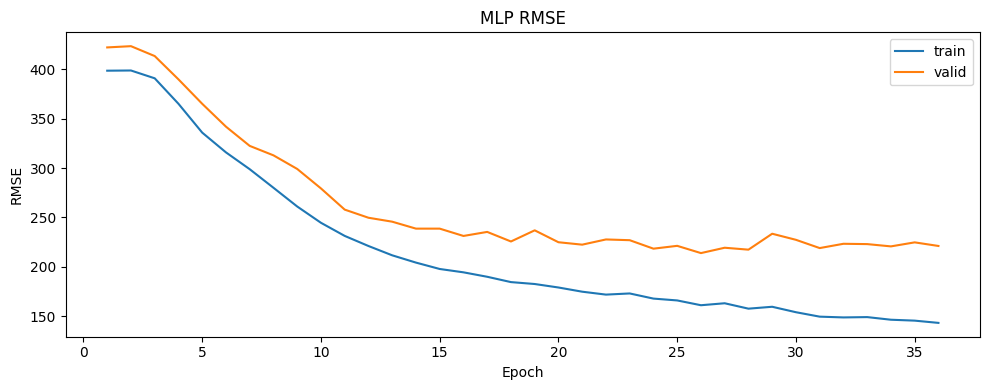

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_history["epoch"], mlp_history["train_rmse"], label="train")
ax.plot(mlp_history["epoch"], mlp_history["valid_rmse"], label="valid")
ax.set_title("MLP RMSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "mlp_rmse.png", dpi=160)
plt.show()


In [ ]:
mlp_true_valid, mlp_pred_valid = mlp_predict(mlp_model, valid_loader)
mlp_valid_metrics = regression_metrics(mlp_true_valid, mlp_pred_valid)
mlp_valid_metrics

{'mae': 129.3883514404297, 'rmse': 213.776332442345, 'r2': 0.7375483512878418}

## Model comparison and 5-fold check

First, models are compared on the validation split. Then we run 5-fold checks on the training part for the strongest candidates to check the robustness.


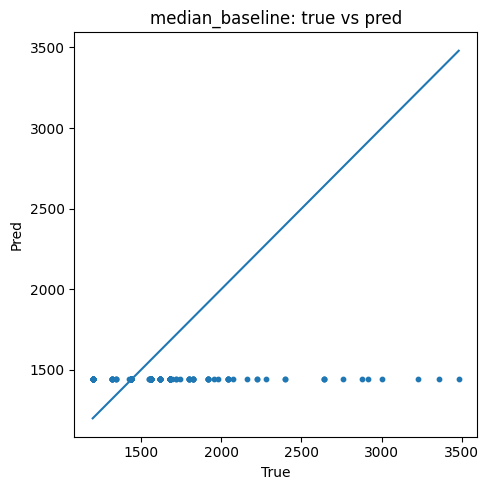

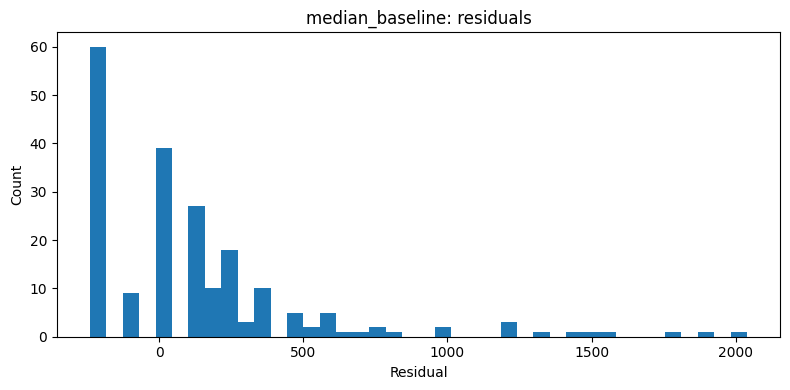

,model,mae,rmse,r2
0,hgb,96.856537,192.598382,0.786973
1,rf,96.668777,204.667346,0.759438
2,enet,117.096420,204.841879,0.759027
3,ridge,117.546837,205.419407,0.757667
4,stack_linear,117.365952,205.838776,0.756676
5,mlp,129.388351,213.776332,0.737548
6,median_baseline,276.136597,435.799373,-0.090695


'hgb'

In [ ]:
median_price = float(np.median(y_train))
median_valid_pred = np.full_like(y_valid, median_price, dtype=np.float32)
median_valid_metrics = regression_metrics(y_valid, median_valid_pred)

with mlflow.start_run(run_name="median_baseline"):
    mlflow.log_params({"strategy": "median", "target_space": "raw_price"})
    mlflow.log_metrics({f"valid_{k}": v for k, v in median_valid_metrics.items()})
    save_regression_plots(y_valid, median_valid_pred, "median_baseline")

leaderboard_df = leaderboard_df.copy()
leaderboard_df.loc[len(leaderboard_df)] = {
    "model": "median_baseline",
    **median_valid_metrics
}
leaderboard_df.loc[len(leaderboard_df)] = {
    "model": "mlp",
    **mlp_valid_metrics
}
leaderboard_df = leaderboard_df.sort_values("rmse").reset_index(drop=True)
display(leaderboard_df)
best_model_name = leaderboard_df.iloc[0]["model"]
top_two = leaderboard_df.head(2)["model"].tolist()
best_model_name


In [ ]:
def kfold_sklearn_metrics(model_factory, X, y_raw, n_splits=5):
    rows = []
    y_log = np.log1p(y_raw)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold, (tr_idx, va_idx) in tqdm(enumerate(kf.split(X), 1)):
        model = model_factory()
        model.fit(X[tr_idx], y_log[tr_idx])
        pred = log_to_price(model.predict(X[va_idx]))
        metrics = regression_metrics(y_raw[va_idx], pred)
        rows.append({"fold": fold, **metrics})
    return pd.DataFrame(rows)

def kfold_median_metrics(X, y_raw, n_splits=5):
    rows = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
        pred = np.full(len(va_idx), np.median(y_raw[tr_idx]), dtype=np.float32)
        metrics = regression_metrics(y_raw[va_idx], pred)
        rows.append({"fold": fold, **metrics})
    return pd.DataFrame(rows)

def kfold_mlp_metrics(X, y_scaled, n_splits=5, epochs=30, patience=5):
    rows = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):
        fold_train_loader = torch.utils.data.DataLoader(
            PriceDataset(X[tr_idx], y_scaled[tr_idx]),
            batch_size=256,
            shuffle=True,
            num_workers=0
        )
        fold_valid_loader = torch.utils.data.DataLoader(
            PriceDataset(X[va_idx], y_scaled[va_idx]),
            batch_size=512,
            shuffle=False,
            num_workers=0
        )

        model = PriceMLP(input_dim=X.shape[1]).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-3)
        criterion = nn.HuberLoss(delta=1.0)
        best_state = None
        best_rmse = float("inf")
        best_epoch = -1

        for epoch in range(1, epochs + 1):
            model.train()
            for xb, yb in fold_train_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                optimizer.zero_grad(set_to_none=True)
                pred = model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                optimizer.step()

            tr_true, tr_pred = mlp_predict(model, fold_train_loader)
            va_true, va_pred = mlp_predict(model, fold_valid_loader)
            va_rmse = regression_metrics(va_true, va_pred)["rmse"]

            if va_rmse < best_rmse:
                best_rmse = va_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch

            if epoch - best_epoch >= patience:
                break

        model.load_state_dict(best_state)
        va_true, va_pred = mlp_predict(model, fold_valid_loader)
        metrics = regression_metrics(va_true, va_pred)
        rows.append({"fold": fold, **metrics})

    return pd.DataFrame(rows)


In [ ]:
cv_results = {}

for name in top_two:
    if name == "median_baseline":
        cv_results[name] = kfold_median_metrics(X_train, y_train)
    elif name == "mlp":
        cv_results[name] = kfold_mlp_metrics(X_train, y_train_scaled)
    else:
        cv_results[name] = kfold_sklearn_metrics(
            lambda: candidate_models[name][0].__class__(**candidate_models[name][0].get_params()),
            X_train,
            y_train
        )

for name, frame in cv_results.items():
    print(name)
    display(frame)
    print(frame.mean(numeric_only=True))


0it [00:00, ?it/s]

0it [00:00, ?it/s]

hgb


,fold,mae,rmse,r2
0,1,96.416512,202.848360,0.739055
1,2,95.715805,201.056118,0.754226
2,3,89.945610,170.181435,0.797832
3,4,94.552589,195.303760,0.773301
4,5,96.261497,184.388506,0.774195


fold      3.000000
mae      94.578403
rmse    190.755636
r2        0.767722
dtype: float64
rf


,fold,mae,rmse,r2
0,1,91.021309,207.816523,0.726116
1,2,89.836075,197.531673,0.762767
2,3,87.030022,175.683320,0.784549
3,4,89.903831,197.708197,0.767685
4,5,91.902344,185.517530,0.771421


fold      3.000000
mae      89.938716
rmse    192.851448
r2        0.762508
dtype: float64


## Final choice and refit

After the comparison the best model is refit on train and valid.


In [ ]:
final_model_name = best_model_name
final_model_name

'hgb'

In [ ]:
X_train_full = np.vstack([X_train, X_valid])
y_train_full = np.concatenate([y_train, y_valid])
y_train_full_log = np.log1p(y_train_full)
y_train_full_scaled = target_scaler.transform(y_train_full_log.reshape(-1, 1)).ravel().astype(np.float32)

if final_model_name == "mlp":
    full_loader = torch.utils.data.DataLoader(
        PriceDataset(X_train_full, y_train_full_scaled),
        batch_size=256,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    final_model = PriceMLP(input_dim=X_train_full.shape[1]).to(device)
    optimizer = torch.optim.AdamW(final_model.parameters(), lr=8e-4, weight_decay=1e-3)
    criterion = nn.HuberLoss(delta=1.0)

    best_epoch = int(mlp_history.loc[mlp_history["valid_rmse"].idxmin(), "epoch"])
    n_epochs_final = max(best_epoch + 5, 20)

    for epoch in range(1, n_epochs_final + 1):
        final_model.train()
        for xb, yb in full_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = final_model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    final_true, final_pred = mlp_predict(final_model, test_loader)
    final_metrics = regression_metrics(final_true, final_pred)
elif final_model_name == "median_baseline":
    median_price = float(np.median(y_train_full))
    final_model = {"median_price": median_price}
    final_pred = np.full_like(y_test, median_price, dtype=np.float32)
    final_metrics = regression_metrics(y_test, final_pred)
else:
    final_model = clone(candidate_models[final_model_name][0])
    final_model.fit(X_train_full, np.log1p(y_train_full))
    final_pred = log_to_price(final_model.predict(X_test))
    final_metrics = regression_metrics(y_test, final_pred)

final_metrics


{'mae': 102.68617248535156,
 'rmse': 233.7393463481277,
 'r2': 0.7216464877128601}

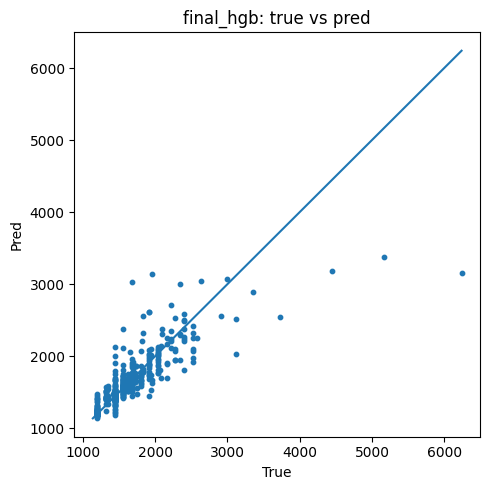

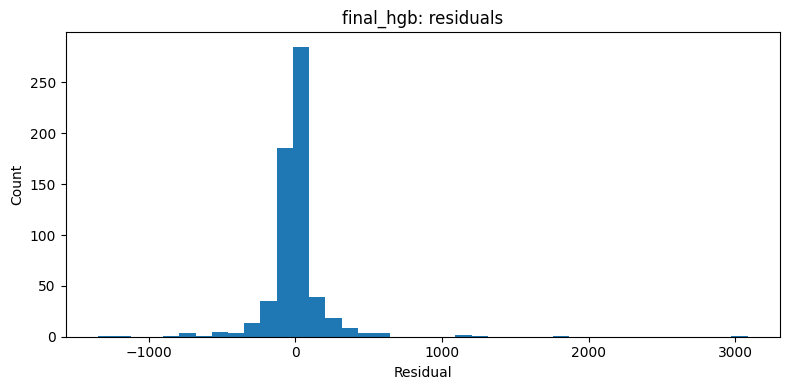

{'mae': 102.68617248535156,
 'rmse': 233.7393463481277,
 'r2': 0.7216464877128601}

In [ ]:
save_regression_plots(y_test, final_pred, f"final_{final_model_name}")

with mlflow.start_run(run_name=f"final_{final_model_name}"):
    mlflow.log_params({"final_model": final_model_name, "feature_count": feature_count, "target_transform": TARGET_TRANSFORM})
    for key, value in final_metrics.items():
        mlflow.log_metric(f"test_{key}", value)

final_metrics


## Saving artifacts and HF handoff

In [ ]:
bundle = {
    "target_col": TARGET_COL,
    "target_transform": TARGET_TRANSFORM,
    "drop_cols": DROP_COLS,
    "num_imputer": numeric_bundle["imputer"],
    "num_scaler": numeric_bundle["scaler"],
    "edition_encoder": edition_bundle["encoder"],
    "publisher_encoder": publisher_bundle["encoder"],
    "grif_fill_value": grif_bundle["fill_value"],
    "cover_fill_value": cover_bundle["fill_value"],
    "series_vocab": series_vocab,
    "series_index": series_index,
    "title_pca": title_pca_bundle["pca_final"],
    "discipline_pca": disc_pca_bundle["pca_final"],
    "theme_pca": theme_pca_bundle["pca_final"],
    "target_scaler": target_scaler,
    "feature_count": feature_count,
    "model_name": final_model_name
}

joblib.dump(bundle, models_dir / "preprocess_bundle.joblib")

if final_model_name == "mlp":
    torch.save({
        "state_dict": final_model.state_dict(),
        "input_dim": X_train_full.shape[1],
        "hidden_dim": 128,
        "dropout": 0.3
    }, models_dir / "final_model.pt")
else:
    joblib.dump(final_model, models_dir / "final_model.joblib")

leaderboard_df.to_csv(artifacts_dir / "leaderboard.csv", index=False)
mlp_history.to_csv(artifacts_dir / "mlp_history.csv", index=False)

with open(artifacts_dir / "feature_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "numeric_cols": NUM_COLS + FORMAT_NUM_COLS,
        "cat_cols": CAT_COLS,
        "multilabel_col": MULTILABEL_COL,
        "disc_col": DISC_COL,
        "theme_col": THEME_COL,
        "text_cols": [TEXT_TITLE_COL, TEXT_ANN_COL],
        "pca": {
            "title_ann": TITLE_ANN_PCA,
            "discipline": DISC_PCA,
            "theme": THEME_PCA
        },
        "feature_count": feature_count
    }, f, ensure_ascii=False, indent=2)


In [ ]:
import faiss

semantic_train_vectors = np.hstack([train_title_ann_pca, train_disc_pca, train_theme_pca]).astype(np.float32)
index = faiss.IndexFlatL2(semantic_train_vectors.shape[1])
index.add(semantic_train_vectors)

faiss.write_index(index, str(artifacts_dir / "knorus_semantic.index"))

meta = train_df[[TEXT_TITLE_COL, TEXT_ANN_COL, TARGET_COL, "Издательство", "Вид издания"]].copy()
meta.to_parquet(artifacts_dir / "knorus_semantic_meta.parquet", index=False)

In [ ]:
HF_MODEL_REPO = "pymlex/knorus-price-regressor"
HF_TOKEN = "YOUR_TOKEN"

if HF_TOKEN:
    api = HfApi(token=HF_TOKEN)
    api.create_repo(repo_id=HF_MODEL_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(
        repo_id=HF_MODEL_REPO,
        repo_type="model",
        folder_path=str(models_dir)
    )

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...models/final_model.joblib:  27%|##7       |  411kB / 1.52MB            

  .../preprocess_bundle.joblib:  27%|##7       |  290kB / 1.07MB            